# Tiền xử lý dữ liệu Twitter15_16
Xử lý lại cột text với `preprocess_text`, loại bỏ các cột không cần thiết, đổi tên `raw_label` thành `label`, và sắp xếp theo thời gian.

In [5]:
import sys
from pathlib import Path

import pandas as pd

ROOT_DIR = Path("..").resolve()
sys.path.append(str(ROOT_DIR))

from src.utils import preprocess_text

input_path = 'twitter15_16.csv'
output_path = 'twitter15_16_preprocessed.csv'

df = pd.read_csv(input_path)
df['text'] = df['content'].astype(str).apply(preprocess_text)
df = df.drop(columns=['content', 'year_season', 'weight', 'label'])
df = df.rename(columns={'raw_label': 'label'})
df['timestamp'] = pd.to_datetime(df['timestamp'], unit='s', errors='coerce')
df = df.sort_values('timestamp').reset_index(drop=True)

df_unique = df.drop_duplicates(subset=['text']).reset_index(drop=True)
df_unique.to_csv(output_path, index=False, encoding='utf-8')

df_unique.head(10)


,id,label,label_id,timestamp,year,month,day,year_month,source_dataset,text
0,80080680482123777,false,1,2011-06-13 01:14:56.710999966,2011,6,13,2011-06,twitter15,seriously racist mcdonald s sign is obviously ...
1,80084555733803009,false,1,2011-06-13 01:30:20.642999887,2011,6,13,2011-06,twitter15,hoax mcdonald s issues official statement on r...
2,91728807081426944,false,1,2011-07-15 04:40:26.503999949,2011,7,15,2011-07,twitter15,#psa please do not drink any pepsi soda a work...
3,265953285247209472,false,1,2012-11-06 23:06:19.032999992,2012,11,6,2012-11,twitter15,deep fried left wings demo crab cakes barack a...
4,273182568298450945,false,1,2012-11-26 21:52:54.426000118,2012,11,26,2012-11,twitter15,42 million dead in bloodiest black friday week...
5,295152287901417472,true,0,2013-01-26 12:52:43.756999969,2013,1,26,2013-01,twitter15,#prayforchristopher 5k run well we are walking...
6,295944137948151809,false,1,2013-01-28 17:19:15.519999981,2013,1,28,2013-01,twitter15,a photo of black nurses saving the life of a k...
7,334722003057647616,false,1,2013-05-15 17:28:39.019999981,2013,5,15,2013-05,twitter15,this is just about the weirdest fetish i ve ev...
8,336873759271157760,true,0,2013-05-21 15:58:57.678999901,2013,5,21,2013-05,twitter15,hasan gets 278k but victims denied army benefi...
9,336913656921083904,true,0,2013-05-21 18:37:30.019999981,2013,5,21,2013-05,twitter15,fort hood shooter reportedly has drawn 278g in...


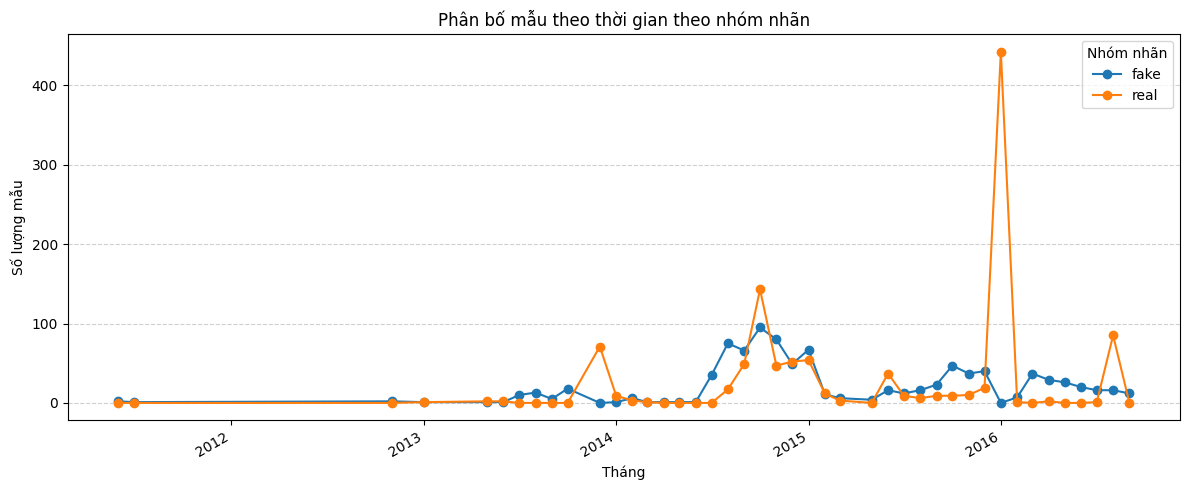

In [7]:
# Vẽ phân bố mẫu theo thời gian với màu theo nhóm nhãn
import matplotlib.pyplot as plt

label_map = {
    'non-rumor': 'real',
    'true': 'real',
    'false': 'fake',
    'unverified': 'fake',
}

df_plot = df_unique.copy()
df_plot['label_group'] = df_plot['label'].map(label_map).fillna(df_plot['label'])
df_plot['month'] = df_plot['timestamp'].dt.to_period('M').dt.to_timestamp()

groups = df_plot.groupby(['month', 'label_group']).size().reset_index(name='count')

pivot = groups.pivot(index='month', columns='label_group', values='count').fillna(0)

plt.figure(figsize=(12, 5))
pivot.plot(kind='line', marker='o', ax=plt.gca())
plt.title('Phân bố mẫu theo thời gian theo nhóm nhãn')
plt.xlabel('Tháng')
plt.ylabel('Số lượng mẫu')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.legend(title='Nhóm nhãn')
plt.tight_layout()
plt.show()


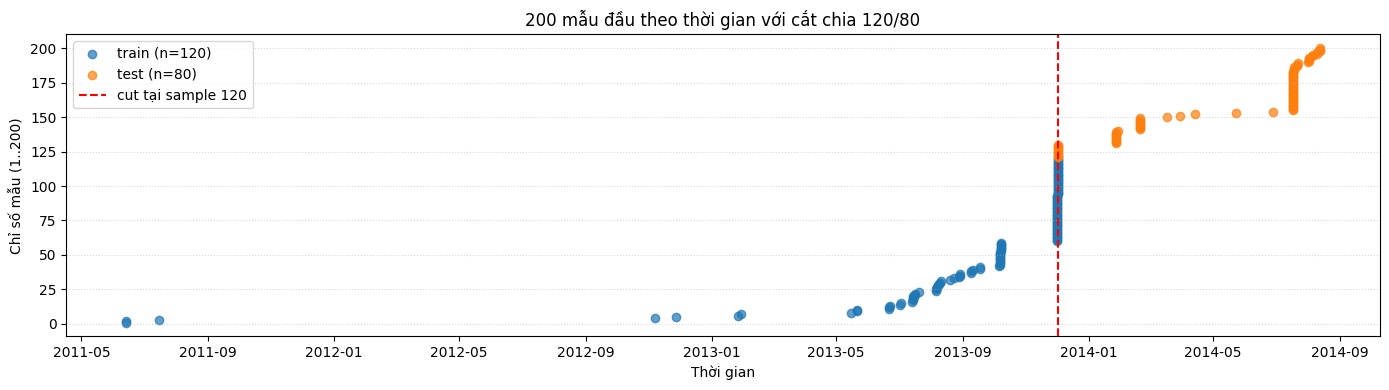

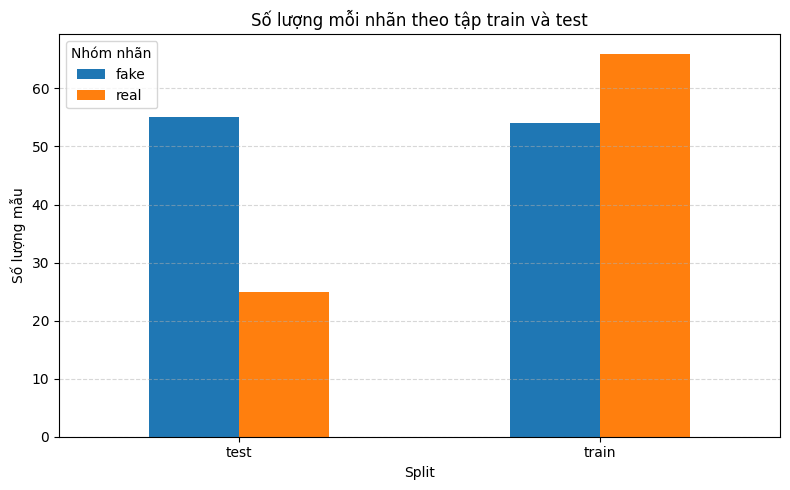

In [14]:
# Hiển thị 200 mẫu đầu và cắt chia 120/80 theo thời gian
import matplotlib.pyplot as plt

n_samples = 200
train_cut = 120

df_200 = df_unique.head(n_samples).copy()
df_200['split'] = ['train'] * train_cut + ['test'] * (len(df_200) - train_cut)
df_200['label_group'] = df_200['label'].map(label_map).fillna(df_200['label'])

boundary_train = df_200.loc[train_cut - 1, 'timestamp'] if len(df_200) >= train_cut else None

plt.figure(figsize=(14, 4))
for split, color in [('train', 'tab:blue'), ('test', 'tab:orange')]:
    subset = df_200[df_200['split'] == split]
    plt.scatter(subset['timestamp'], subset.index + 1, label=f'{split} (n={len(subset)})', color=color, alpha=0.7)

if boundary_train is not None:
    plt.axvline(boundary_train, color='red', linestyle='--', label=f'cut tại sample {train_cut}')

plt.title('200 mẫu đầu theo thời gian với cắt chia 120/80')
plt.xlabel('Thời gian')
plt.ylabel('Chỉ số mẫu (1..200)')
plt.legend()
plt.grid(axis='y', linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

# Biểu đồ số lượng mỗi label theo split train/test
counts = (
    df_200.groupby(['split', 'label_group'])
    .size()
    .reset_index(name='count')
    .pivot(index='split', columns='label_group', values='count')
    .fillna(0)
)

counts.plot(kind='bar', figsize=(8, 5))
plt.title('Số lượng mỗi nhãn theo tập train và test')
plt.xlabel('Split')
plt.ylabel('Số lượng mẫu')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(title='Nhóm nhãn')
plt.tight_layout()
plt.show()
